# Analysing Sports Footwear Consumer Behaviour by Income, Gender, and Channel

This project examines transaction-level sports footwear sales data to identify patterns in customer purchasing behaviour. The analysis explores how customer characteristics, sales channels, product categories, and brands relate to revenue, demand, and market segmentation.

## Research Question

How can sports footwear customers be better understood and targeted using differences in income level, gender, sales channel, product category, and brand performance?

## Target Audience

This analysis is intended for a *marketing manager* or *business decision-maker* who wants to better understand customer segments, product demand, and channel performance in order to support targeting, promotions, and campaign planning.

## Dataset

**Dataset:** *Sports Footwear Sales and Consumer Behavior*  
**Source:** Kaggle, accessed through `kagglehub`
**Accessed on:** 20 April 2026

The dataset contains transaction-level records of sports footwear purchases, including information on product category, brand, gender, sales channel, pricing, revenue, customer income level, country, and customer rating.

## This analysis includes

- data loading and initial exploration
- data cleaning and preparation
- comparison of product category performance
- comparison of brand performance
- analysis of customer segments by income level and gender
- comparison of online and retail sales channels
- monthly trend and seasonal pattern analysis
- combined segmentation analysis
- visualisation of key findings using Python

## Data Loading
The dataset is accessed from Kaggle using `kagglehub`, then loaded into a pandas DataFrame for analysis.

In [1]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download dataset
path = kagglehub.dataset_download("aliiihussain/sports-footwear-sales-and-consumer-behavior")
print("Path to dataset files:", path)

# Locate CSV files
csv_files = []
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("CSV files found:", csv_files)

# Load dataset
df = pd.read_csv(csv_files[0])

# Quick inspection
df.head()

Path to dataset files: C:\Users\muden\.cache\kagglehub\datasets\aliiihussain\sports-footwear-sales-and-consumer-behavior\versions\1
CSV files found: ['C:\\Users\\muden\\.cache\\kagglehub\\datasets\\aliiihussain\\sports-footwear-sales-and-consumer-behavior\\versions\\1\\global_sports_footwear_sales_2018_2026.csv']


,order_id,order_date,brand,model_name,category,gender,size,color,base_price_usd,discount_percent,final_price_usd,units_sold,revenue_usd,payment_method,sales_channel,country,customer_income_level,customer_rating
0,ORD100000,2021-01-30,ASICS,Model-370,Running,Unisex,8,Black,162,15,137.70,1,137.7,Card,Retail Store,Germany,Low,4.6
1,ORD100001,2026-10-05,Reebok,Model-314,Lifestyle,Men,8,Grey,80,5,76.00,3,228.0,Card,Online,USA,Low,3.9
2,ORD100002,2023-11-12,ASICS,Model-763,Lifestyle,Men,8,Black,176,15,149.60,4,598.4,Cash,Retail Store,India,Medium,3.0
3,ORD100003,2026-08-29,Reebok,Model-905,Basketball,Women,7,White,61,15,51.85,2,103.7,Card,Retail Store,India,High,3.4
4,ORD100004,2019-11-09,Nike,Model-413,Training,Men,11,Black,80,0,80.00,4,320.0,Cash,Online,USA,Medium,3.0


## Initial Inspection

This section examines the dataset’s size, columns, data types, missing values, duplicate rows, and summary statistics. The aim is to understand the structure and quality of the data before cleaning and analysis.

In [2]:
print("Shape of dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData types and non-null counts:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

print("\nSummary statistics:")
print(df.describe().to_string())

Shape of dataset: (30000, 18)

Columns:
Index(['order_id', 'order_date', 'brand', 'model_name', 'category', 'gender',
       'size', 'color', 'base_price_usd', 'discount_percent',
       'final_price_usd', 'units_sold', 'revenue_usd', 'payment_method',
       'sales_channel', 'country', 'customer_income_level', 'customer_rating'],
      dtype='object')

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               30000 non-null  object 
 1   order_date             30000 non-null  object 
 2   brand                  30000 non-null  object 
 3   model_name             30000 non-null  object 
 4   category               30000 non-null  object 
 5   gender                 30000 non-null  object 
 6   size                   30000 non-null  int64  
 7   color                  30000 n

## Data Cleaning and Preparation

The dataset is relatively clean, with no missing values or duplicate rows. However, some preparation is still needed before analysis.

In this section:
- `order_date` is converted to datetime format,
- new time variables are created,
- customer income level is ordered as a category,
- and revenue is checked for consistency with price and units sold.

These steps improve the dataset for analysis and visualisation.

In [3]:
# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# Create time-based columns
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month

# Order income level as a categorical variable
income_order = ['Low', 'Medium', 'High']
df['customer_income_level'] = pd.Categorical(
    df['customer_income_level'],
    categories=income_order,
    ordered=True
)

# Validate revenue calculation
df['calculated_revenue'] = df['final_price_usd'] * df['units_sold']
print("Revenue matches calculated revenue:",
      np.allclose(df['revenue_usd'], df['calculated_revenue']))

df[['order_date', 'year', 'month', 'customer_income_level']].head()

Revenue matches calculated revenue: True


,order_date,year,month,customer_income_level
0,2021-01-30,2021,1,Low
1,2026-10-05,2026,10,Low
2,2023-11-12,2023,11,Medium
3,2026-08-29,2026,8,High
4,2019-11-09,2019,11,Medium


In [4]:
print("Missing dates after conversion:", df['order_date'].isnull().sum())
print("Revenue validation passed:",
      np.allclose(df['revenue_usd'], df['final_price_usd'] * df['units_sold']))

Missing dates after conversion: 0
Revenue validation passed: True


### Cleaning Results

The dataset required minimal cleaning. No missing values or duplicate rows were found, order_date was successfully converted to datetime format, and revenue values were confirmed to be consistent with final_price_usd × units_sold.


## Analysis Plan

To answer the business question, we will look at:
1. **Income level and spending** – to examine whether purchase value differs across customer income groups.
2. **Gender and category preferences** – to identify whether product preferences vary by gender.
3. **Sales channel behaviour** – to compare purchasing patterns across online and retail channels.
4. **Combined visualisation** – to explore how income level, gender, and sales channel interact in shaping customer behaviour.
5. **Monthly sales patterns** – to examine how units sold vary by product category over time.
6. **Discount effects** – to assess whether higher discount levels are associated with greater units sold

## Analysis 1: Income level and spending
This section examines whether purchasing value differs across customer income groups

## 1: Average rev per order 

In [27]:
income_summary = df.groupby('customer_income_level', observed=False)[
    ['final_price_usd', 'units_sold', 'revenue_usd']
].mean().round(2)
print(income_summary)

                       final_price_usd  units_sold  revenue_usd
customer_income_level                                          
Low                             121.86        2.51       305.77
Medium                          120.69        2.49       300.40
High                            120.55        2.50       302.00


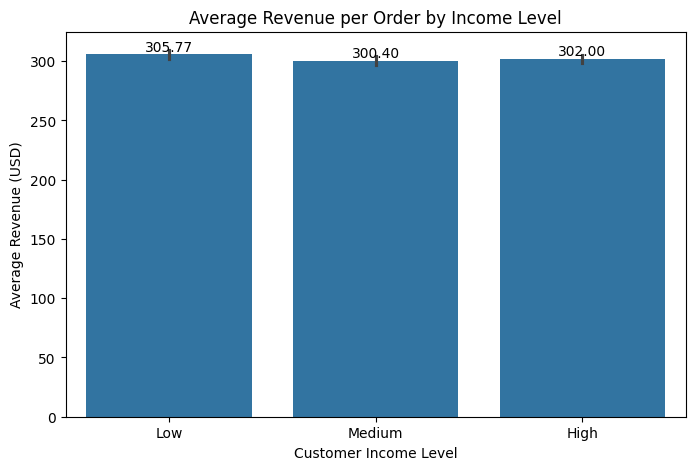

In [31]:
plt.figure(figsize=(8,5))
ax = sns.barplot(data=df, x='customer_income_level', y='revenue_usd')

plt.title('Average Revenue per Order by Income Level')
plt.xlabel('Customer Income Level')
plt.ylabel('Average Revenue (USD)')

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.show()

Low-income customers have the highest average revenue per order, while medium-income customers have the lowest; however, the differences between all three income groups are very small

## 2: Brand Preference by Income level 

In [7]:
brand_income = pd.crosstab(df['customer_income_level'], df['brand'], normalize='index') * 100
brand_income.round(2)

brand,ASICS,Adidas,New Balance,Nike,Puma,Reebok
customer_income_level,,,,,,
Low,17.54,16.71,16.56,16.03,16.58,16.57
Medium,17.04,16.22,16.27,16.98,16.48,17.01
High,16.75,16.24,16.98,17.17,16.17,16.68


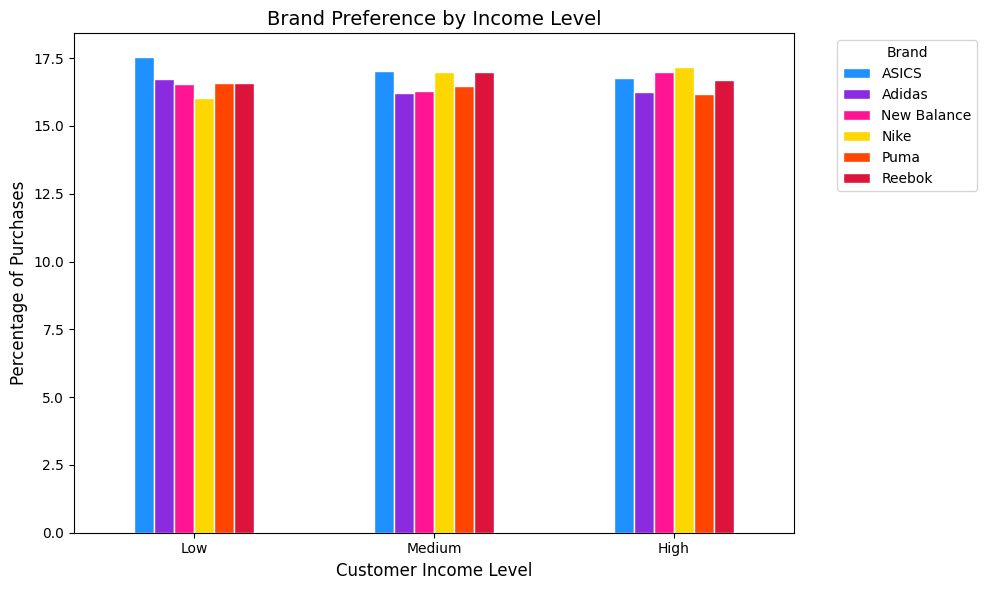

In [8]:
hot_colors = ['#1E90FF', '#8A2BE2', '#FF1493', '#FFD700', '#FF4500', '#DC143C']

brand_income.plot(
    kind='bar',
    figsize=(10,6),
    color=hot_colors,
    edgecolor='white'
)

plt.title('Brand Preference by Income Level', fontsize=14)
plt.xlabel('Customer Income Level', fontsize=12)
plt.ylabel('Percentage of Purchases', fontsize=12)
plt.legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3: Shoe category preference by Income level 

In [9]:
category_income = pd.crosstab(df['customer_income_level'], df['category'], normalize='index') * 100
category_income.round(2)

category,Basketball,Gym,Lifestyle,Running,Training
customer_income_level,,,,,
Low,19.93,19.84,20.01,20.57,19.65
Medium,20.24,19.41,20.30,19.85,20.22
High,20.57,19.42,20.28,19.43,20.31


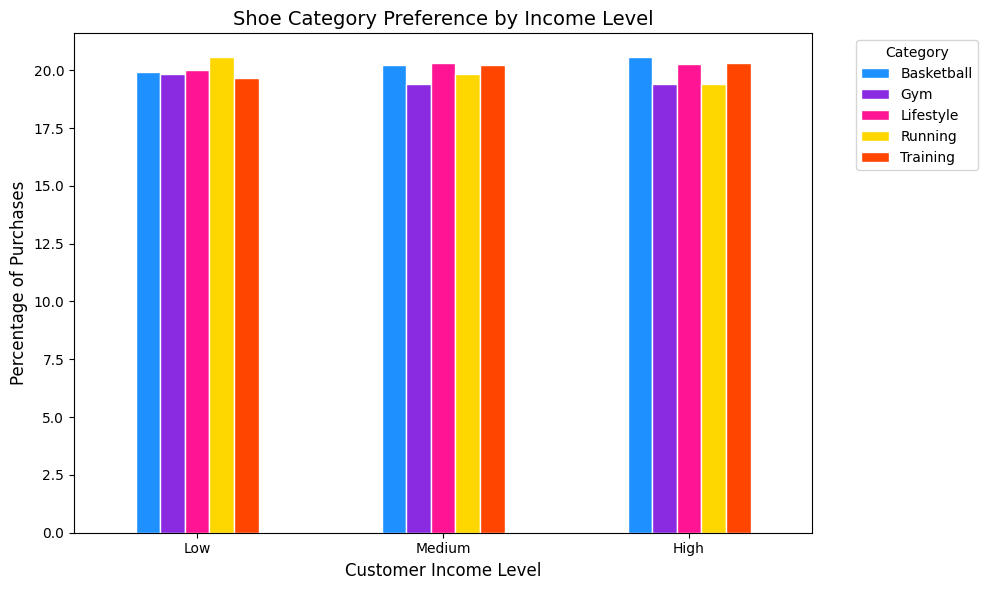

In [10]:
hot_colors = ['#1E90FF', '#8A2BE2', '#FF1493', '#FFD700', '#FF4500']

category_income.plot(
    kind='bar',
    figsize=(10,6),
    color=hot_colors,
    edgecolor='white'
)

plt.title('Shoe Category Preference by Income Level', fontsize=14)
plt.xlabel('Customer Income Level', fontsize=12)
plt.ylabel('Percentage of Purchases', fontsize=12)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Analysis 1: Conclusion
The results suggest that customer income level has only a limited effect on purchasing behavior. Average revenue per order is very similar across income groups, while brand and shoe category preferences remain broadly consistent. Overall, income level does not appear to be a major driver of customer purchase patterns in this dataset.


## Analysis 2: Gender and Product Category Preferences

This section explores whether customer gender is associated with product category preferences.

In [11]:
gender_category_table = pd.crosstab(df['gender'], df['category'])
print(gender_category_table) 

category  Basketball   Gym  Lifestyle  Running  Training
gender                                                  
Men             2017  1972       2030     1987      2069
Unisex          2018  1909       2009     1974      1958
Women           2039  1985       2020     2022      1991


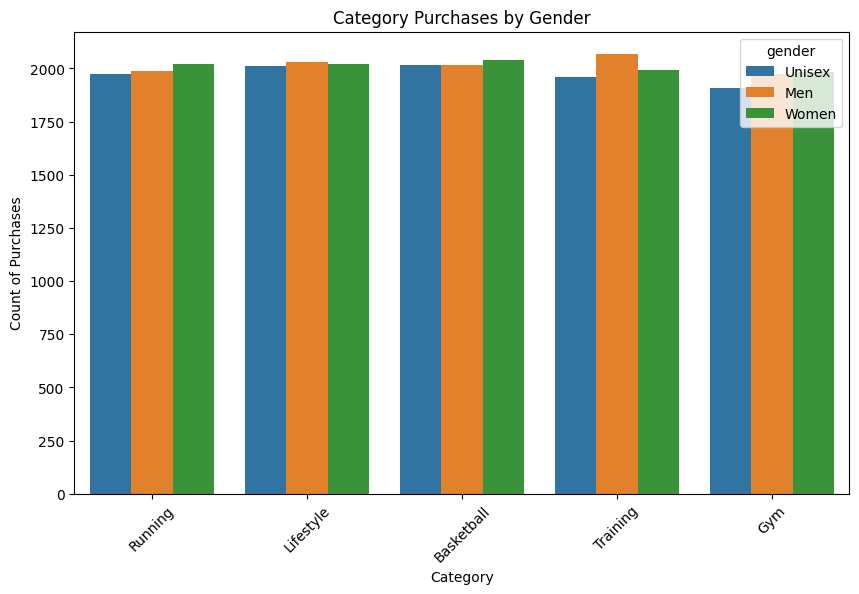

In [12]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='category', hue='gender')
plt.title('Category Purchases by Gender')
plt.xlabel('Category')
plt.ylabel('Count of Purchases')
plt.xticks(rotation=45)
plt.show()

**Brand purchased by Gender**

In [13]:
gender_brand_prop = pd.crosstab(df['gender'], df['brand'], normalize='index').round(2)
print(gender_brand_prop)

brand   ASICS  Adidas  New Balance  Nike  Puma  Reebok
gender                                                
Men      0.17    0.16         0.17  0.16  0.16    0.17
Unisex   0.17    0.16         0.16  0.17  0.16    0.17
Women    0.18    0.17         0.16  0.17  0.17    0.16


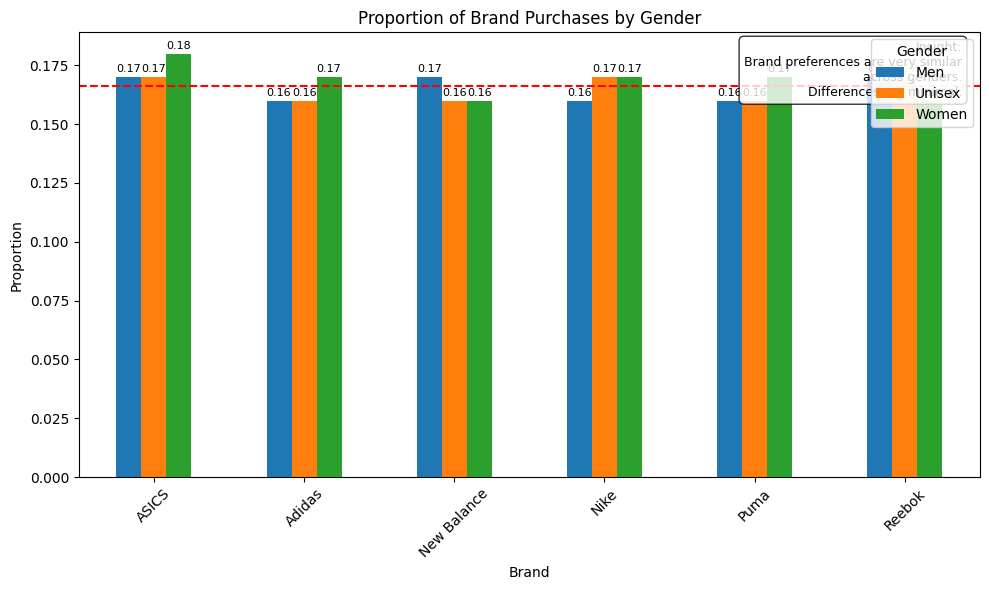

In [14]:
ax = gender_brand_prop.T.plot(kind='bar', figsize=(10,6))

plt.title('Proportion of Brand Purchases by Gender')
plt.xlabel('Brand')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.legend(title='Gender', loc='upper right')
plt.tight_layout()

# Add horizontal reference line at average proportion
avg_prop = gender_brand_prop.values.mean()
plt.axhline(y=avg_prop, color='red', linestyle='--', linewidth=1.5, label='Average proportion')

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=2, fontsize=8)

# Add insight annotation box
ax.text(
    0.98, 0.98,
    'Insight:\nBrand preferences are very similar\nacross genders.\nDifferences are minimal.',
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8)
)

plt.show()

## Analysis 2: Conclusion
Overall, the gender analysis suggests that purchasing behaviour is largely consistent across gender groups. Both product category and brand preferences show only minor differences, indicating that gender is not a major factor influencing customer choices in this dataset.Men more intersted in training shoes.

## Analysis 3: Sales Channel and Sales Performance

This section investigates whether sales performance differs across sales channels. Specifically, it compares average revenue, final price, and units sold between online and retail store purchases.

The purpose is to determine whether one sales channel performs better than the other and to identify which channel contributes more strongly to sales outcomes.

In [16]:
channel_summary = df.groupby('sales_channel')[['revenue_usd', 'final_price_usd', 'units_sold']].mean().round(2)
print(channel_summary)

               revenue_usd  final_price_usd  units_sold
sales_channel                                          
Online              302.89           120.86         2.5
Retail Store        302.54           121.20         2.5


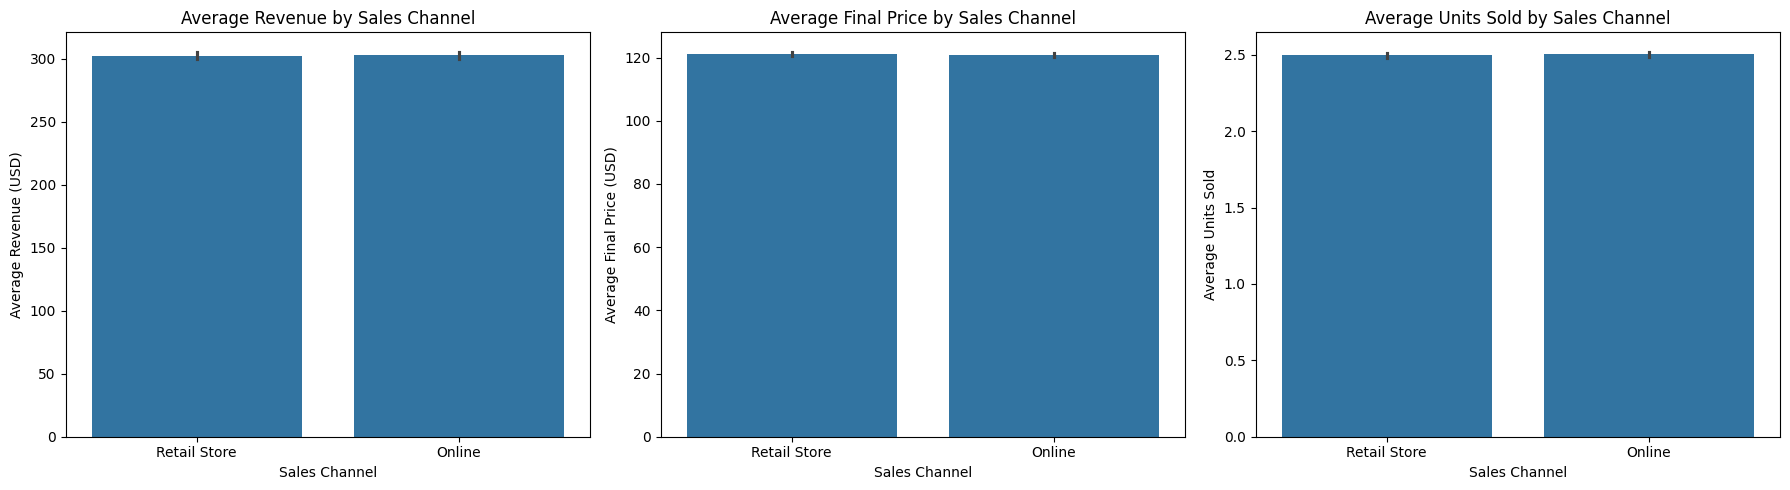

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.barplot(data=df, x='sales_channel', y='revenue_usd', estimator=np.mean, ax=axes[0])
axes[0].set_title('Average Revenue by Sales Channel')
axes[0].set_xlabel('Sales Channel')
axes[0].set_ylabel('Average Revenue (USD)')

sns.barplot(data=df, x='sales_channel', y='final_price_usd', estimator=np.mean, ax=axes[1])
axes[1].set_title('Average Final Price by Sales Channel')
axes[1].set_xlabel('Sales Channel')
axes[1].set_ylabel('Average Final Price (USD)')

sns.barplot(data=df, x='sales_channel', y='units_sold', estimator=np.mean, ax=axes[2])
axes[2].set_title('Average Units Sold by Sales Channel')
axes[2].set_xlabel('Sales Channel')
axes[2].set_ylabel('Average Units Sold')

plt.tight_layout()
plt.show()

## Analysis 3: Conclusion
Overall, the sales channel analysis shows that sales performance is very similar between Online and Retail Store purchases. Average revenue, final price, and units sold are nearly identical across both channels, suggesting that neither channel significantly outperforms the other in this dataset.

## Combined Segmentation Analysis: Income Level, Gender, and Sales Channel

This analysis combines the three previous factors, income level, gender, and sales channel, to examine their joint effect on purchasing behaviour

In [17]:
combined_segmentation = df.groupby(
    ['customer_income_level', 'gender', 'sales_channel']
)['revenue_usd'].mean().reset_index()

combined_segmentation

C:\Users\muden\AppData\Local\Temp\ipykernel_22736\420083949.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combined_segmentation = df.groupby(


,customer_income_level,gender,sales_channel,revenue_usd
0,Low,Men,Online,297.096974
1,Low,Men,Retail Store,308.424838
2,Low,Unisex,Online,301.329746
3,Low,Unisex,Retail Store,298.379709
4,Low,Women,Online,316.118758
5,Low,Women,Retail Store,312.828478
6,Medium,Men,Online,296.705365
7,Medium,Men,Retail Store,299.282972
8,Medium,Unisex,Online,303.847338
9,Medium,Unisex,Retail Store,295.238330


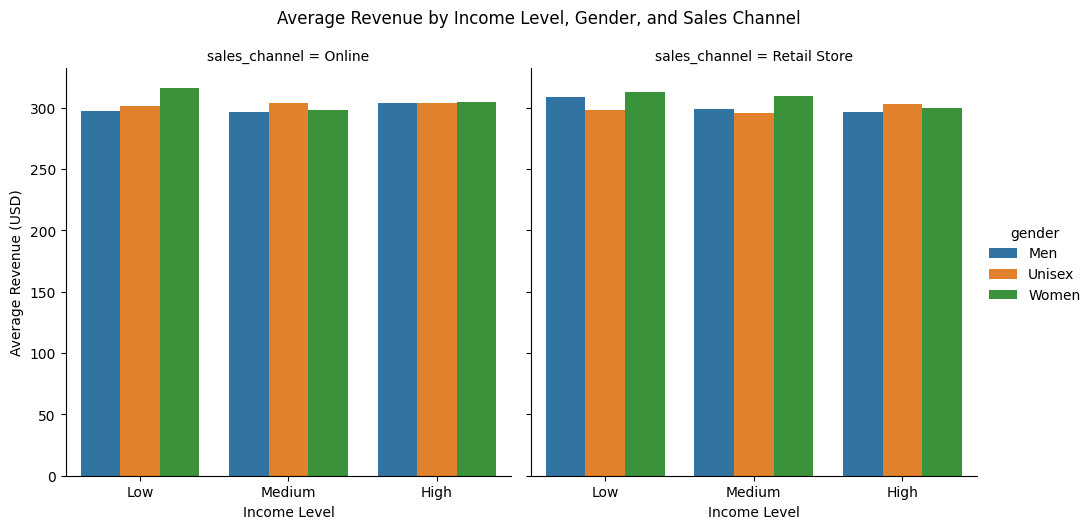

In [18]:
g = sns.catplot(
    data=combined_segmentation,
    x='customer_income_level',
    y='revenue_usd',
    hue='gender',
    col='sales_channel',
    kind='bar',
    height=5,
    aspect=1
)

g.fig.suptitle('Average Revenue by Income Level, Gender, and Sales Channel', y=1.05)
g.set_axis_labels('Income Level', 'Average Revenue (USD)')
plt.show()

## Conclusion
Overall, the combined analysis shows only small differences in average revenue across income level, gender, and sales channel combinations. The highest average revenue was generated by low-income women shopping online, with an average revenue of approximately 316.12 USD.



## Analysis 4: Monthly Units Sold by Category
 This analysis looks at sales performance by month using data from 2019, 2021, 2023, and 2026. Monthly sales were combined across these years to identify overall trends, and the average monthly sales level was used as a benchmark to highlight stronger and weaker months. This can help indicate when promotions may be more or less effective.

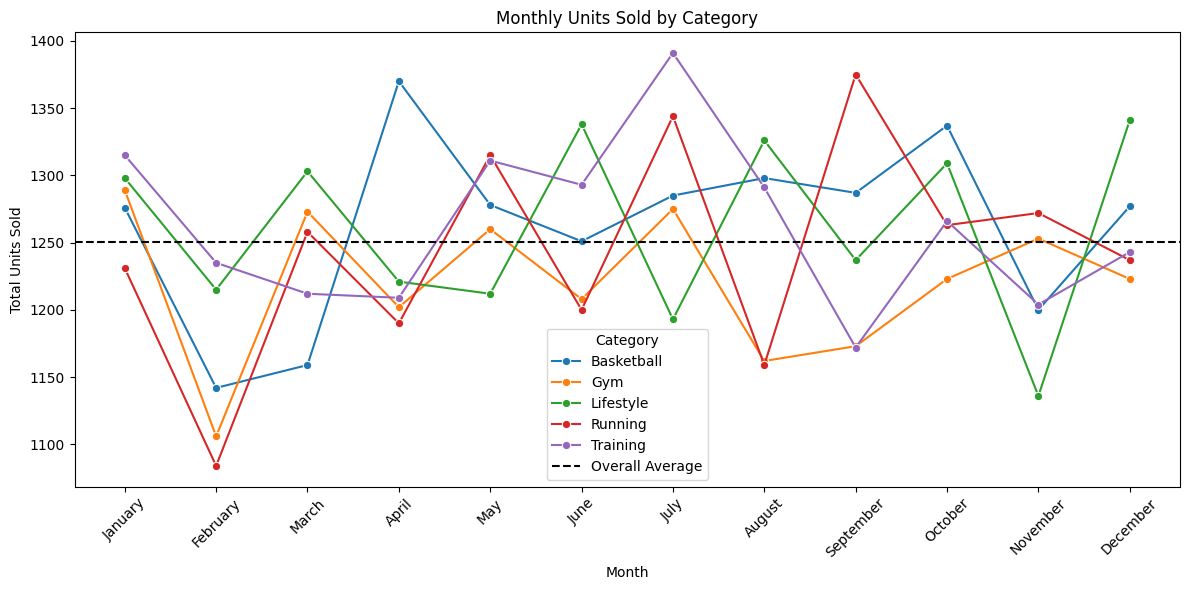

In [40]:
# Create month number and month name
df['month_num'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.month_name()

# Group by month and category
monthly_category_sales = (
    df.groupby(['month_num', 'month_name', 'category'])['units_sold']
    .sum()
    .reset_index()
    .sort_values('month_num')
)

# Calculate overall average units sold
monthly_avg = monthly_category_sales['units_sold'].mean()

# Plot line chart
plt.figure(figsize=(12,6))
sns.lineplot(
    data=monthly_category_sales,
    x='month_name',
    y='units_sold',
    hue='category',
    marker='o'
)

# Add average line
plt.axhline(y=monthly_avg, color='black', linestyle='--', linewidth=1.5, label='Overall Average')

plt.title('Monthly Units Sold by Category')
plt.xlabel('Month')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=45)
plt.legend(title='Category')
plt.tight_layout()
plt.show()

## Analysis 4: Monthly Units Sold by Category
- Sales change across the months, showing clear seasonal patterns by category.
- February is the weakest month overall, with most categories seeing a drop in sales.
- Basketball shoes sell best in April.
- Training shoes perform best in July and across the summer months.
- Running shoes reach their peak in September.
- Lifestyle shoes show their biggest drop in November.
- Based on this, promotions and discounts should be targeted in weaker months like February and November, while marketing should be increased before peak months to boost sales further.

In [20]:
discount_summary = df.groupby('discount_percent')[['units_sold', 'revenue_usd']].mean().reset_index()
print(discount_summary)

   discount_percent  units_sold  revenue_usd
0                 0    2.487628   346.773889
1                 5    2.503841   333.858292
2                10    2.499599   313.938448
3                15    2.486399   293.036378
4                20    2.510621   283.445067
5                30    2.512692   245.078913


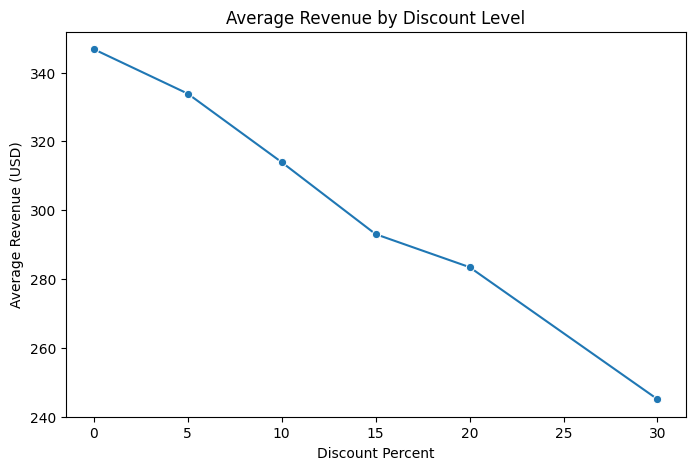

In [21]:
plt.figure(figsize=(8,5))
sns.lineplot(data=discount_summary, x='discount_percent', y='revenue_usd', marker='o')
plt.title('Average Revenue by Discount Level')
plt.xlabel('Discount Percent')
plt.ylabel('Average Revenue (USD)')
plt.show()

Because revenue is calculated from final price and units sold, a negative relationship between discount and revenue is expected unless discounts lead to a meaningful increase in purchase volume. In this dataset, units sold remain stable across discount levels, so revenue declines as discounts rise

## Overall project conclusion
This project analysed sports footwear consumer behaviour using customer income level, gender, sales channel, product category, brand performance, and monthly sales trends. The results show that income level, gender, and sales channel have only limited influence on purchasing behaviour, as average revenue, brand preference, and category choice remain broadly similar across these groups.

The most useful insight comes from the monthly and category-based analysis, which shows clearer seasonal patterns in customer demand. Certain product categories perform better in specific months, while weaker months such as February and November may benefit from additional promotional activity. This suggests that businesses should focus more on product timing, seasonal marketing, and category planning rather than relying heavily on demographic differences alone.

Overall, the findings indicate that sports footwear customers in this dataset are relatively balanced across segments, but stronger business value can be gained by using seasonal demand patterns and category performance to guide targeting, promotions, and campaign planning